**Import Dependencies**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

Data Collection and Processing


In [4]:
data = pd.read_csv("/content/Rainfall.csv")

In [5]:
data.shape

(366, 12)

In [6]:
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [7]:
data["day"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [9]:
data.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [10]:
data= data.drop(columns=["day"])

In [19]:
data.columns = data.columns.str.strip()
print(data)

     pressure  maxtemp  temparature  mintemp  dewpoint  humidity  cloud  \
0      1025.9     19.9         18.3     16.8      13.1        72     49   
1      1022.0     21.7         18.9     17.2      15.6        81     83   
2      1019.7     20.3         19.3     18.0      18.4        95     91   
3      1018.9     22.3         20.6     19.1      18.8        90     88   
4      1015.9     21.3         20.7     20.2      19.9        95     81   
..        ...      ...          ...      ...       ...       ...    ...   
361    1022.7     18.8         17.7     16.9      15.0        84     90   
362    1026.6     18.6         17.3     16.3      12.8        75     85   
363    1025.9     18.9         17.7     16.4      13.3        75     78   
364    1025.3     19.2         17.3     15.2      13.3        78     86   
365    1026.4     20.5         17.8     15.5      13.0        74     66   

    rainfall  sunshine  winddirection  windspeed  
0        yes       9.3           80.0       26.3

In [12]:
data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,1


In [21]:
# Fill missing values
data["winddirection"] = data["winddirection"].fillna(
    data["winddirection"].mode()[0]
)

data["windspeed"] = data["windspeed"].fillna(
    data["windspeed"].median()
)

Exploratory Data Analysis


In [22]:
# setting plot style for all the plots
sns.set(style="whitegrid")

In [32]:
data.head()


,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [23]:
data.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.284153,21.534153
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.722827,10.056054
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [24]:
data.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

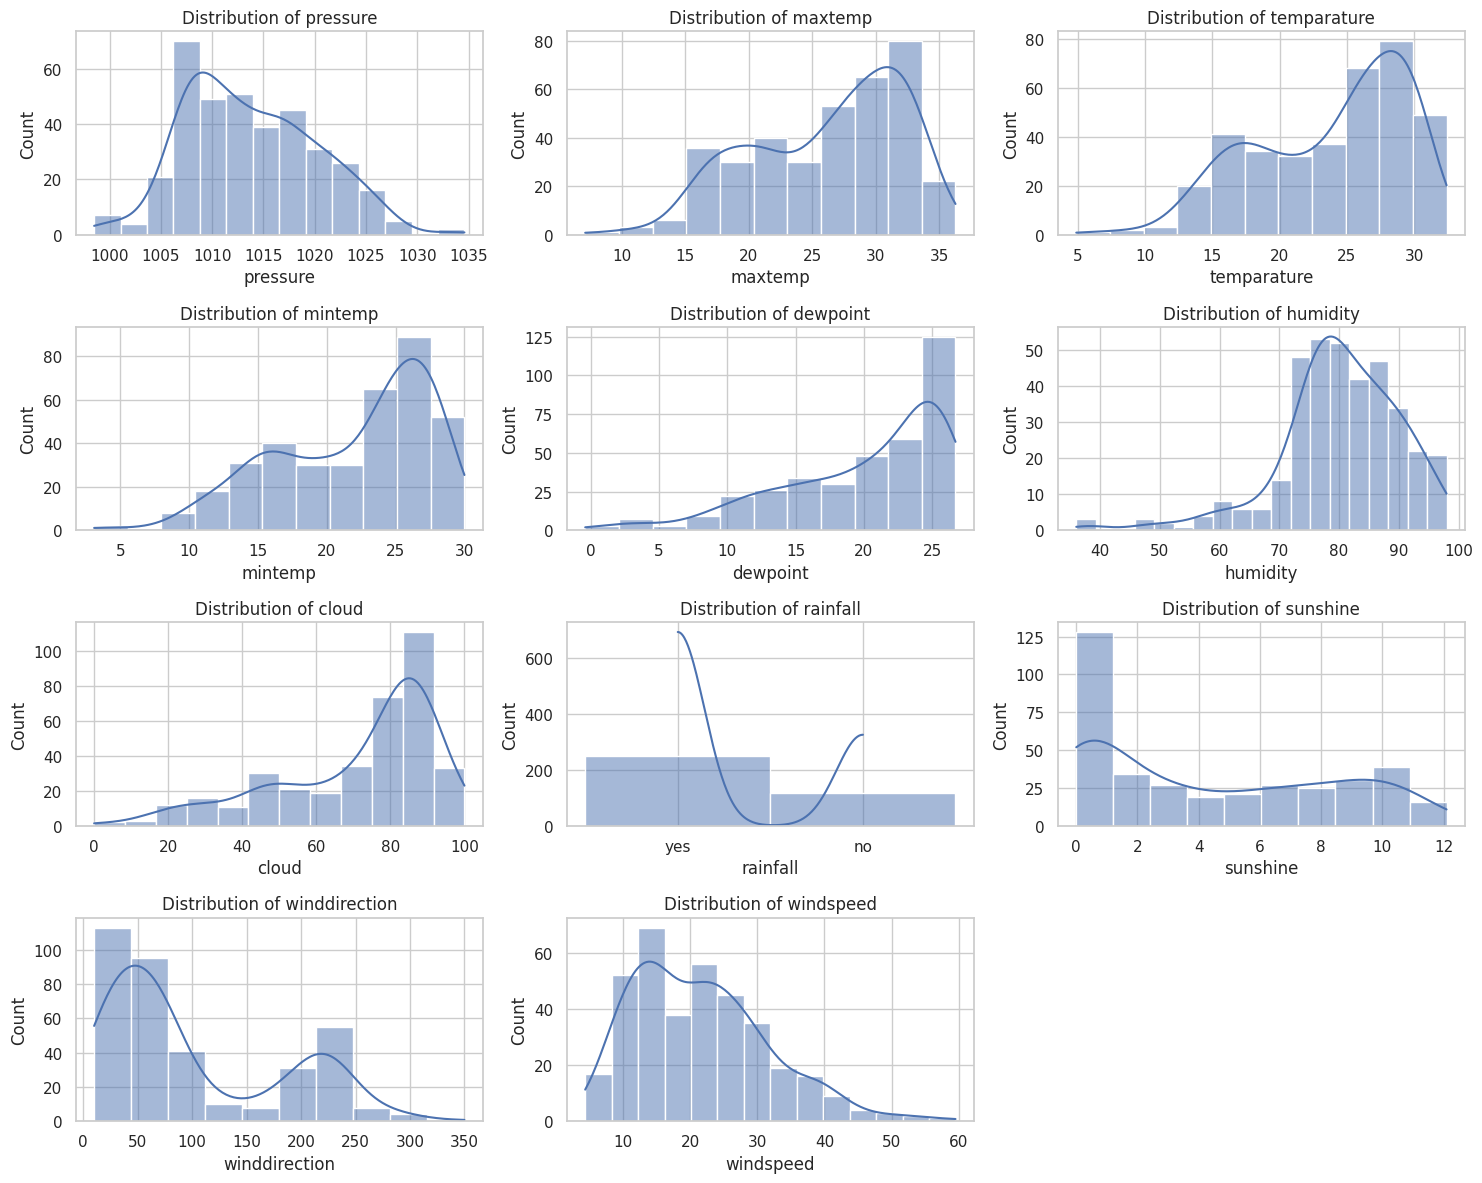

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = [
    'pressure', 'maxtemp', 'temparature', 'mintemp',
    'dewpoint', 'humidity', 'cloud', 'rainfall',
    'sunshine', 'winddirection', 'windspeed'
]

plt.figure(figsize=(15, 12))

for i, column in enumerate(columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(data[column], kde=True)
    plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

In [33]:
data["rainfall"] = data["rainfall"].map({"yes": 1, "no": 0})

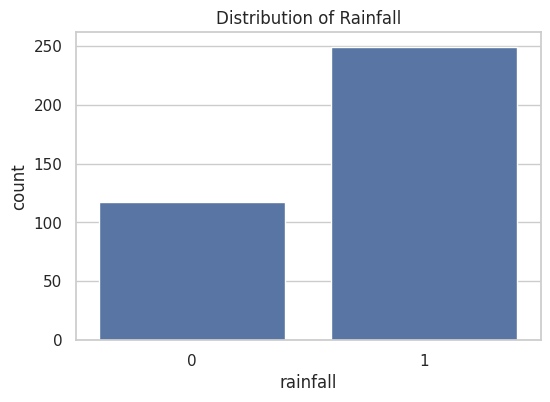

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x="rainfall", data=data)
plt.title("Distribution of Rainfall")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

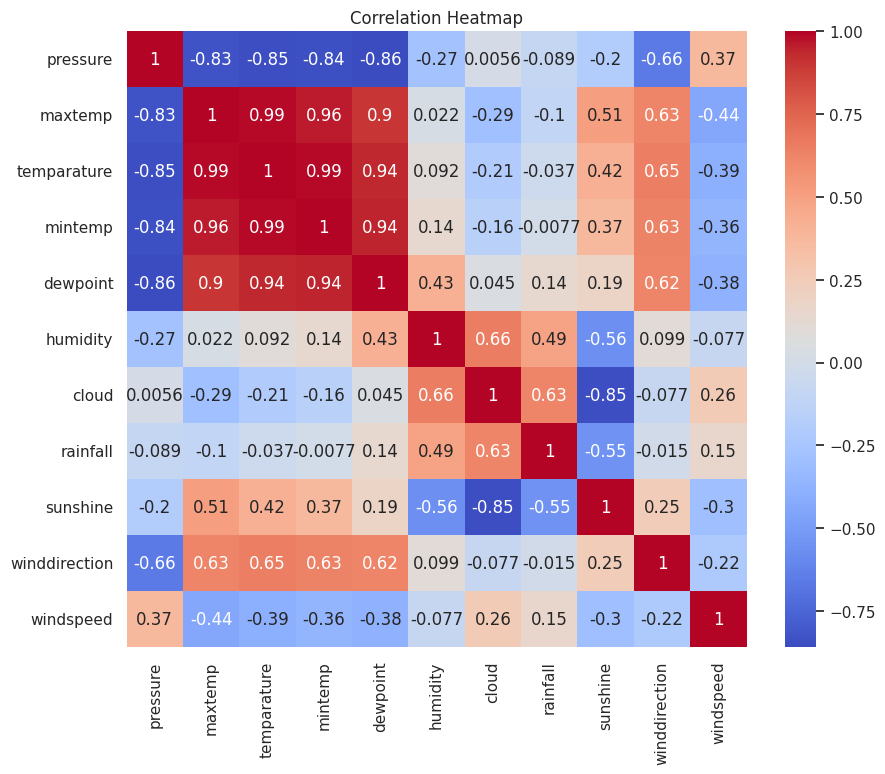

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show

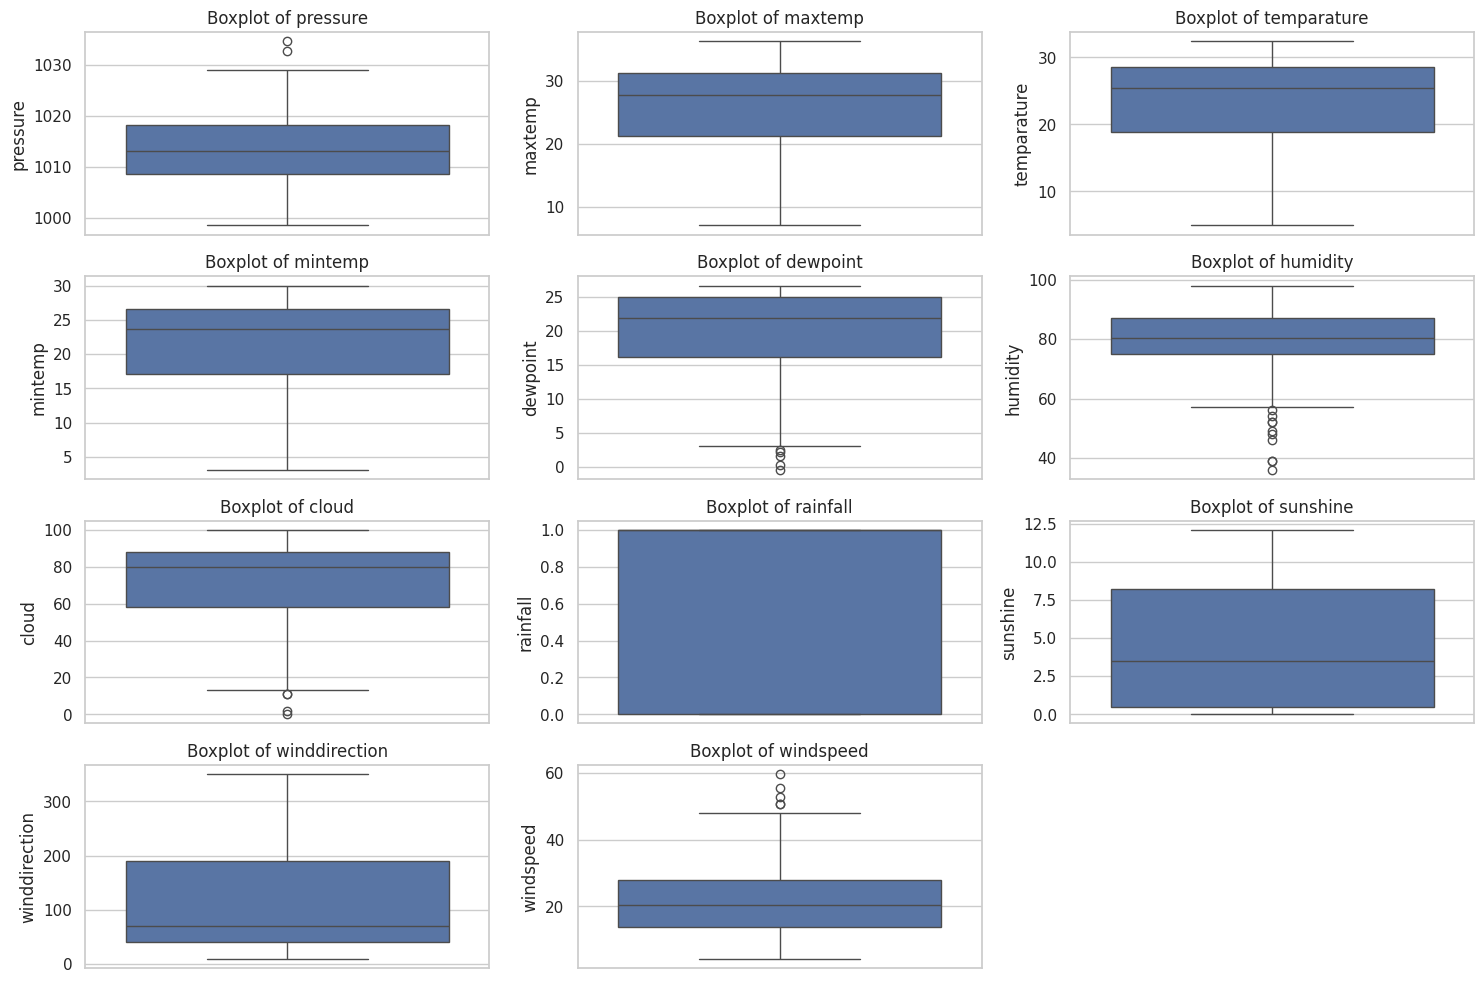

In [36]:
plt.figure(figsize=(15,10))

columns = [
    'pressure', 'maxtemp', 'temparature', 'mintemp',
    'dewpoint', 'humidity', 'cloud', 'rainfall',
    'sunshine', 'winddirection', 'windspeed'
]
for i, column in enumerate(columns, 1):
  plt.subplot(4,3,i)
  sns.boxplot(data[column])
  plt.title(f"Boxplot of {column}")
plt.tight_layout()
plt.show()

DATA PROCESSING

In [38]:
data= data.drop(columns=['maxtemp','mintemp','temparature'])

In [40]:
data["rainfall"].value_counts()

,count
rainfall,
1,249
0,117


In [41]:
df_majority = data[data["rainfall"]==1]
df_minority = data[data["rainfall"]==0]

In [43]:
df_minority.shape

(117, 8)

In [45]:
df_majority.shape

(249, 8)

In [47]:
# downsample the majority class

df_majority_downsampled = resample(df_majority,
                                  replace=False,
                                  n_samples=len(df_minority),
                                  random_state=42)

In [48]:
df_majority_downsampled.shape

(117, 8)

In [49]:
df_downsampled = pd.concat([df_majority_downsampled,df_minority])

In [50]:
df_downsampled = df_downsampled.sample(frac =1, random_state=42).reset_index(drop=True)

In [51]:
df_downsampled["rainfall"].value_counts()

,count
rainfall,
1,117
0,117


In [52]:
# split features and target as X and y
X = df_downsampled.drop(columns=["rainfall"])
y = df_downsampled["rainfall"]

In [53]:
# Splitting test and train data set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Model Training


In [54]:
rf_model =RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [50,100,200],
    "max_features": ["sqrt","log2"],
    "max_depth": [None,10,20,30],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [55]:
# Hypertuning using GridSearchCV

grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [56]:
best_rf_model = grid_search_rf.best_estimator_

print("best parameter for RF : ",grid_search_rf.best_params_)

best parameter for RF :  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}


Model Evaluation

In [58]:
cv_scores = cross_val_score(best_rf_model,X_train,y_train, cv=5)
print("Cross validation score: ",cv_scores)
print("Mean cross validation score: ",np.mean(cv_scores))

Cross validation score:  [0.68421053 0.81578947 0.83783784 0.83783784 0.91891892]
Mean cross validation score:  0.818918918918919


In [60]:
# test dataset performance
y_pred = best_rf_model.predict(X_test)

print("Test set Accuracy:", accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("Classification Report:\n", classification_report(y_test,y_pred))

Test set Accuracy: 0.7446808510638298
Confusion Matrix:
 [[17  7]
 [ 5 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74        24
           1       0.72      0.78      0.75        23

    accuracy                           0.74        47
   macro avg       0.75      0.75      0.74        47
weighted avg       0.75      0.74      0.74        47



Unknown Data prediction


In [65]:
input_data = (1015.9,19.9,95,81,0.0,40.0,13.7)
input_df = pd.DataFrame([input_data], columns=[
    'pressure',
    'dewpoint', 'humidity', 'cloud',
    'sunshine', 'winddirection', 'windspeed'
])

prediction = best_rf_model.predict(input_df)

print("Prediction Result:","Rainfall" if prediction[0]==1 else "No Rainfall")

Prediction Result: Rainfall


In [68]:
# save model
model_data ={"model": best_rf_model, "feature_names":X.columns.tolist()}

with open("rainfall_prediction_model.pkl","wb") as file:
  pickle.dump(model_data,file)